In [4]:
# Problem 1 Data Read,Write and Inspect

import pandas as pd

#1 Load the provided dataset and import in pandas DataFrame.
bank_df = pd.read_csv("/content/drive/MyDrive/Datasets/Week2/bank.csv")

#2 Checking Info
print(bank_df.info())

#a Find object columns
obj_cols = bank_df.select_dtypes(include="object").columns
print()
print("Object Columns:", obj_cols)

#b Unique values of object columns
for col in obj_cols:
    print()
    print(f"Unique values in {col}:")
    print(bank_df[col].unique())

#c Total number of null values in each column
print(bank_df.isnull().sum())

#3 Drop all object columns
bank_numeric = bank_df.drop(columns=obj_cols)

# Save to CSV
bank_numeric.to_csv("banknumericdata.csv", index=False)
print("Saved to banknumericdata.csv'")

#4 Read the saved file and print summary statistics
bank_numeric_2 = pd.read_csv("banknumericdata.csv")
print(bank_numeric_2.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Object Columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact'

In [23]:
#Problem 2 (Data imputations)


# 1. Load Dataset
med_df = pd.read_csv("/content/drive/MyDrive/Datasets/Week2/medical_students_dataset.csv")
print(med_df.info())

# 2
null_cols = med_df.columns[med_df.isnull().any()]
print("Columns with missing values:", null_cols)

# 3 Fill missing values
from sklearn.impute import SimpleImputer
import numpy as np

for col in null_cols:
    if med_df[col].dtype in ['int64', 'float64']:
        med_df[col].fillna(med_df[col].mean())
        print(f"Filled numeric column '{col}' using MEAN")

    else:
        med_df[col].fillna(med_df[col].mode()[0])
        print(f"Filled categorical column '{col}' using MODE")

# 4 Check for duplicates
duplicates = med_df.duplicated().sum()
print("Total duplicate rows:", duplicates)

# Remove duplicates if any
med_df_cleaned = med_df.drop_duplicates()
print("Duplicates removed (if existed).")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.8+ MB
None
Columns with missing values: Index(['Student ID', 'Age', 'Gender', 'Height', 'Weight', 'Blood Type', 'BMI',
       'Temperature', 'Heart Rate

Fare Mean: 84.1546875
Fare Median: 60.287499999999994
Fare Max: 512.3292
Fare Min: 0.0
The no. of null values in Age: 177
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


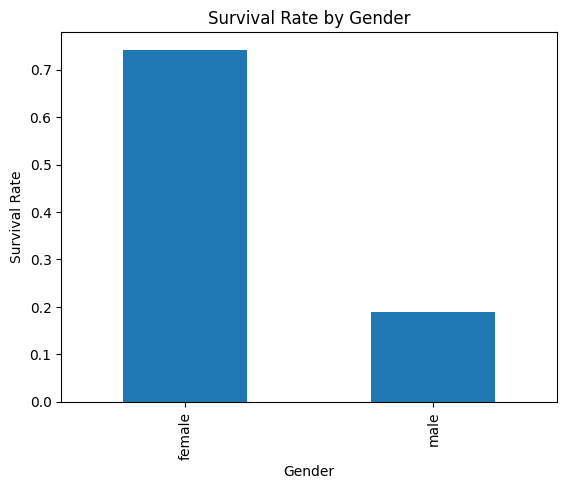

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


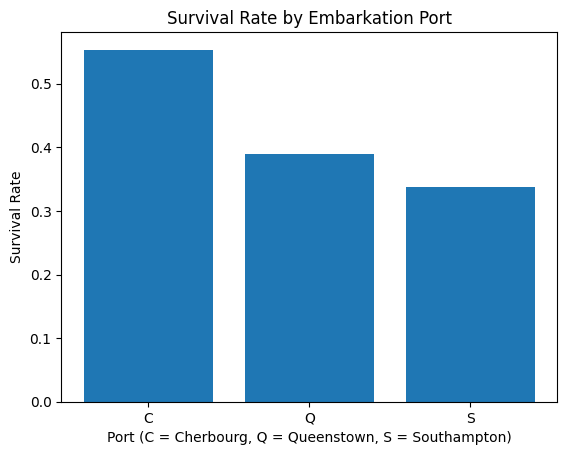

In [22]:
# Data Cleaning and Transformations with "Titanic Dataset"

#Problem -1

titanic_df = pd.read_csv("/content/drive/MyDrive/Datasets/Week2/Titanic-Dataset.csv")


# Subset columns
subset = titanic_df[['Name','Pclass','Sex','Age','Fare','Survived']]

# Keep only first class passengers
first_class = subset[subset['Pclass'] == 1]

# Describe fare statistics
fare_mean = first_class['Fare'].mean()
fare_median = first_class['Fare'].median()
fare_max = first_class['Fare'].max()
fare_min = first_class['Fare'].min()

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Max:", fare_max)
print("Fare Min:", fare_min)

#Problem 2
# Count null values
null_age_count = subset['Age'].isnull().sum()
print("The no. of null values in Age:", null_age_count)

# Drop rows where Age is null
subset_no_null = subset.dropna(subset=['Age'])


#Problem 3

#One-hot encoding
embarked_dummies = pd.get_dummies(titanic_df['Embarked'], prefix="Embarked")

#Add to original DataFrame
titanic2 = pd.concat([titanic_df, embarked_dummies], axis=1)

#Drop original column
titanic2.drop(columns=['Embarked'], inplace=True)

# 4. Show modified DataFrame
titanic2.head()



#Problem 4 Compare mean Survival Rates

import matplotlib.pyplot as plt

# Mean survival by gender
survival_by_gender = titanic_df.groupby('Sex')['Survived'].mean()
print(survival_by_gender)

# Plot
survival_by_gender.plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()


#Problem 5 Draw visualization by the port of embarkation
# Drop rows where Embarked is missing
titanic_cleaned = titanic_df.dropna(subset=['Embarked'])

# Calculate survival rate for each port
survival_by_port = titanic_cleaned.groupby('Embarked')['Survived'].mean()

print(survival_by_port)

# Plot using matplotlib
plt.bar(survival_by_port.index, survival_by_port.values)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Port (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Survival Rate")
plt.show()

